In [2]:
# Demo script to load and plot cGAN forecast data.
import os
from datetime import datetime

# These are the functions that you can use:
from show_forecasts.show_cGAN import (
    load_GAN_forecast,
    plot_GAN_forecast,
    plot_GAN_ensemble,
)
from show_forecasts.show_cGAN import plot_GAN_threshold_chance
from show_forecasts.show_cGAN import (
    load_GAN_forecast,
    plot_GAN_forecast,
    plot_GAN_ensemble,
)
from show_forecasts.show_cGAN import plot_GAN_threshold_chance

In [3]:
from show_forecasts.data_utils import load_env_file

load_env_file()

mask_region = os.getenv("MASK_REGION", None)
use_ui_fs = os.getenv("USE_UI_FS", "")
cgan_ui_fs = True if use_ui_fs.lower() in ["t", "true", "y", "yes", "1"] else False
data_dir = os.environ["GAN_DATA_DIR"]

print("Mask Region: ", mask_region)
print("Data Dir: ", data_dir)

Mask Region:  East Africa
Data Dir:  /home/jason/.docker-data/cgan-data/ftp


In [4]:
# The date that the forecast was initialised
forecast_init_date = datetime(year=2025, month=2, day=12)
# Pick today instead:
# forecast_init_date = datetime.now()
loader_args = {
    "model": "mvua-kubwa-ens",
    "init_date": forecast_init_date,
    "init_time": "00",
    "data_dir": data_dir,
    "cgan_ui_fs": cgan_ui_fs,
}

if mask_region is not None:
    loader_args.update({"mask_region": mask_region})
    
# Load the GAN forecast
data = load_GAN_forecast(**loader_args)
data

<xarray.Dataset>
Dimensions:          (latitude: 384, longitude: 352, member: 50, time: 1,
                      valid_time: 7)
Coordinates:
  * latitude         (latitude) float32 -13.65 -13.55 -13.45 ... 24.55 24.65
  * longitude        (longitude) float32 19.15 19.25 19.35 ... 54.05 54.15 54.25
  * member           (member) int32 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time             (time) datetime64[ns] 2025-02-12
Dimensions without coordinates: valid_time
Data variables:
    fcst_valid_time  (time, valid_time) datetime64[ns] ...
    precipitation    (time, member, valid_time, latitude, longitude) float32 ...
Attributes:
    description:  GAN 24-hour rainfall ensemble members in the ICPAC region.

In [5]:
data.fcst_valid_time.values

array([['2025-02-12T06:00:00.000000000', '2025-02-13T06:00:00.000000000',
        '2025-02-14T06:00:00.000000000', '2025-02-15T06:00:00.000000000',
        '2025-02-16T06:00:00.000000000', '2025-02-17T06:00:00.000000000',
        '2025-02-18T06:00:00.000000000']], dtype='datetime64[ns]')

In [6]:
data.time.values

array(['2025-02-12T00:00:00.000000000'], dtype='datetime64[ns]')

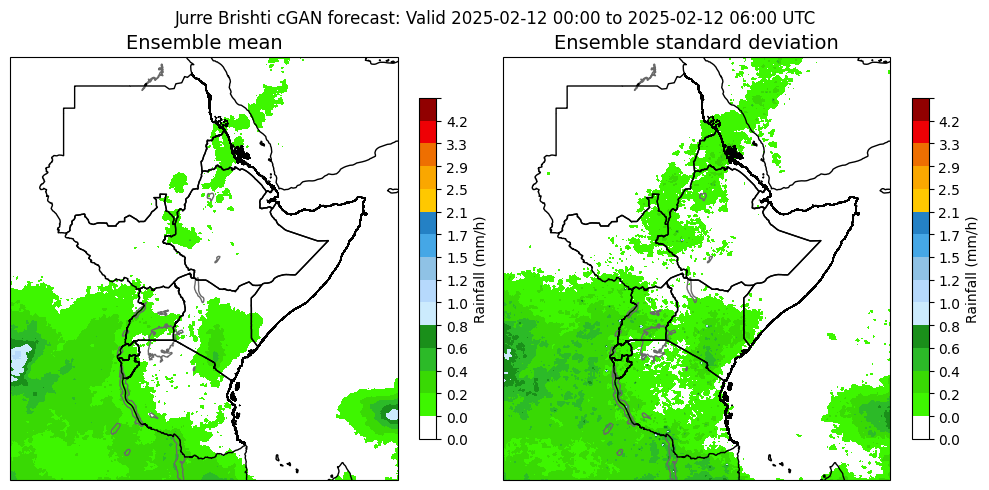

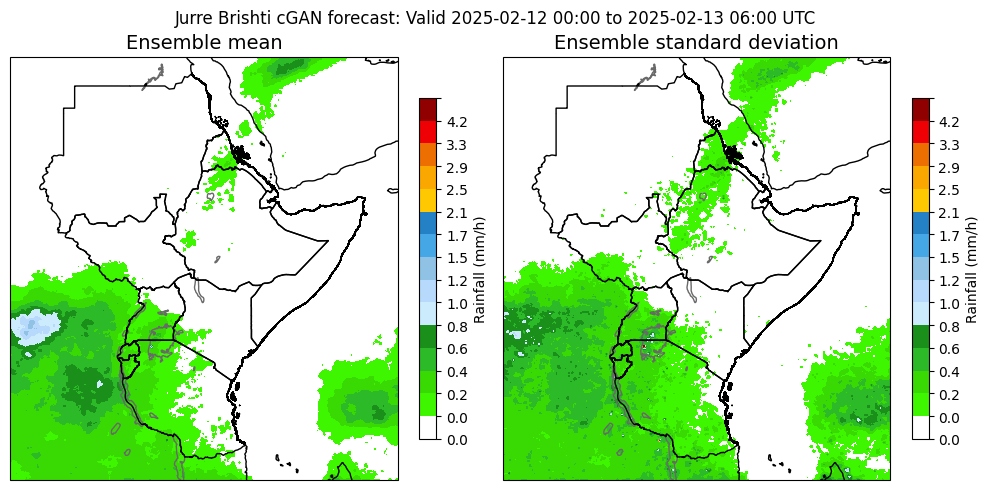

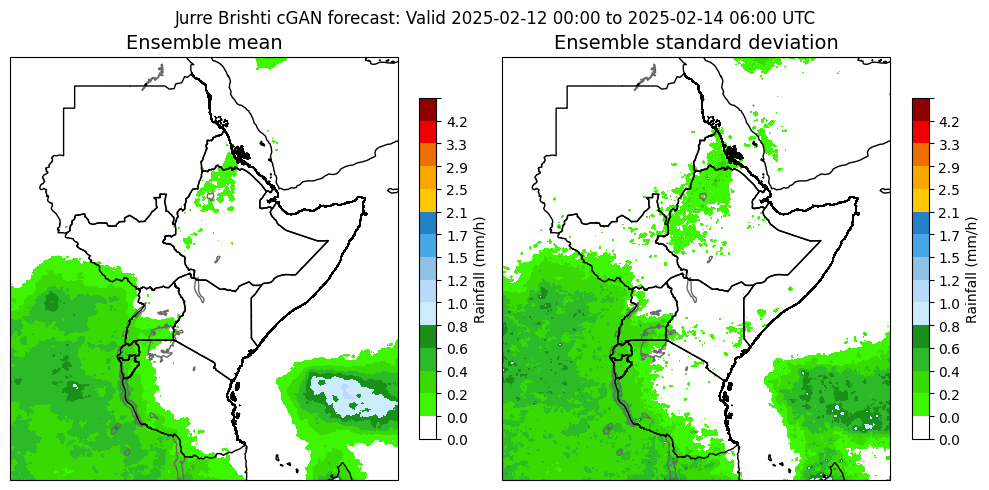

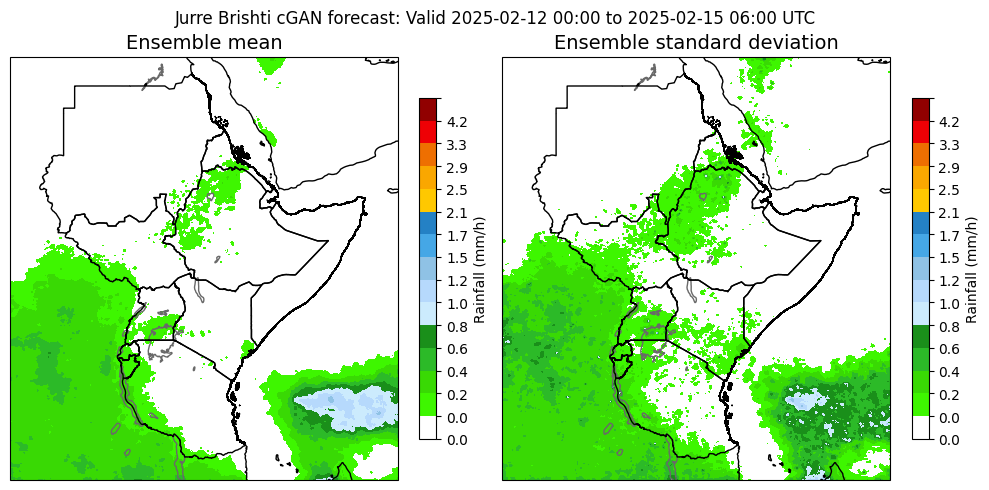

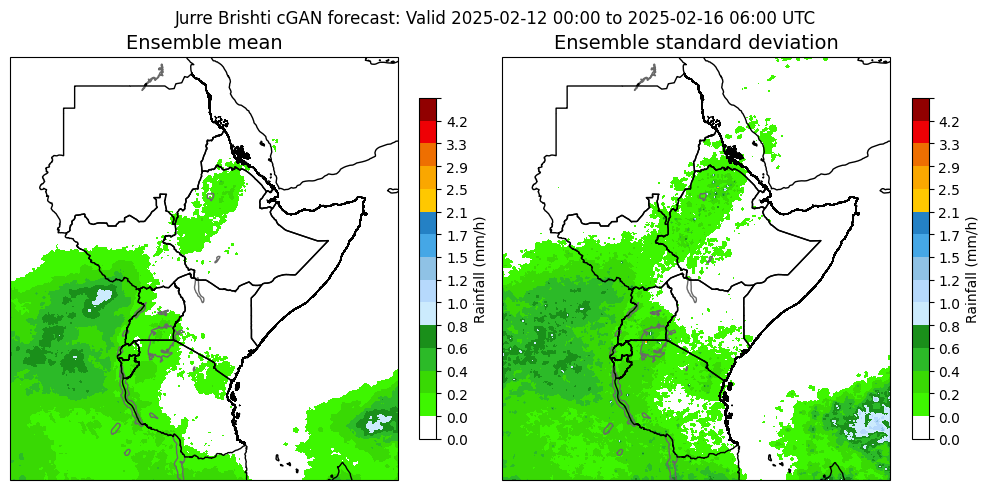

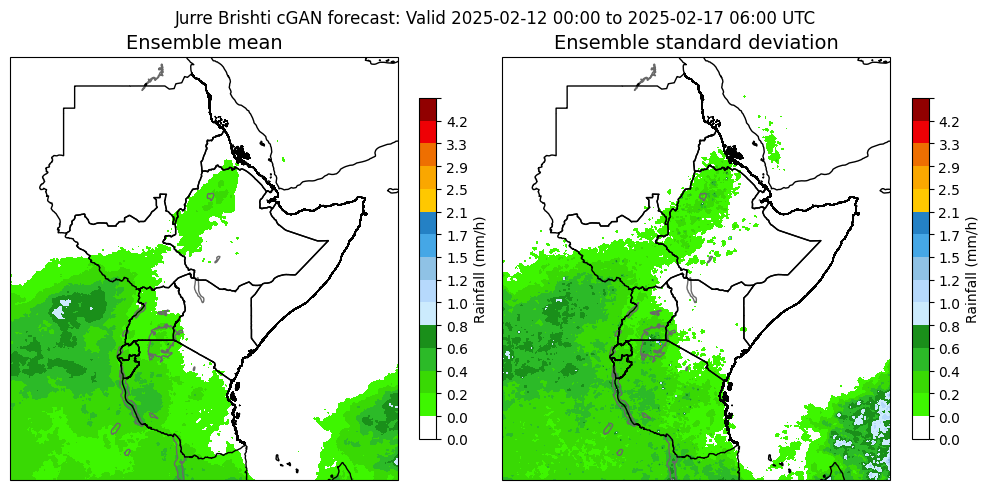

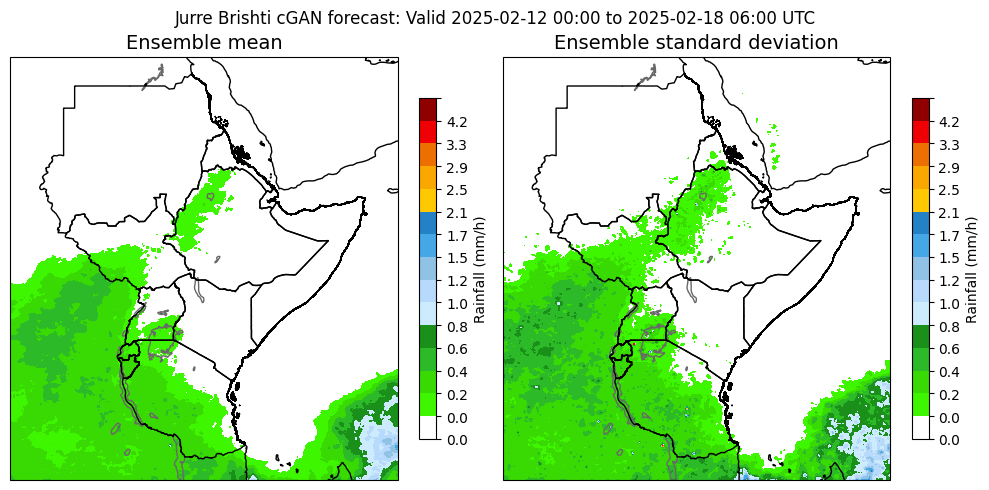

In [4]:
# Plot the GAN forecast
plot_GAN_forecast(
    data,
    style="KMD",
    model="mvua-kubwa-ens",
    region=mask_region,
    file_name="mvua-kubwa-ens-20250212.png",
)

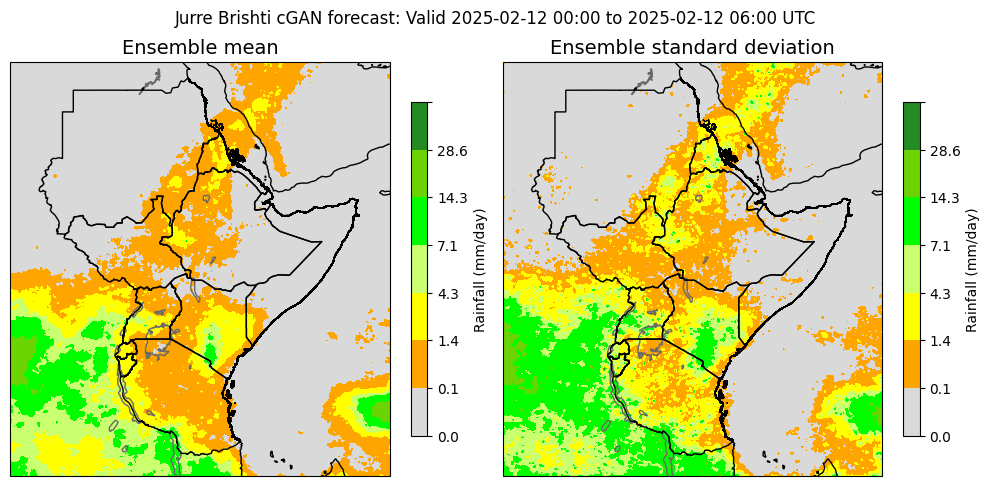

In [5]:
plot_GAN_forecast(
    data,
    model="mvua-kubwa-ens",
    valid_time_start_hour="06h",
    style="ICPAC",
    plot_units="mm/day",
    region=mask_region,
    file_name="mvua-kubwa-ens-20250212.png"
)

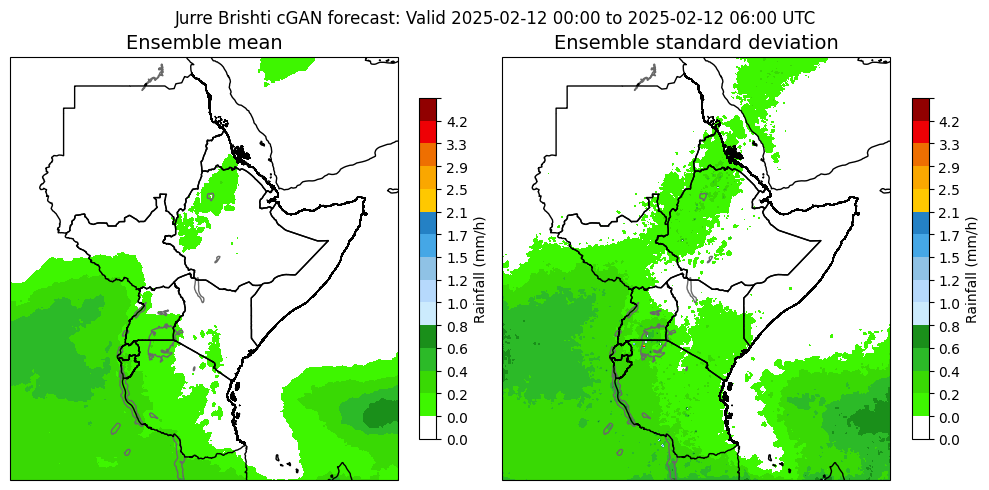

In [6]:
# Plot the rainfall over 24 hours
plot_GAN_forecast(
    data,
    model="mvua-kubwa-ens",
    accumulation_time="24h",
    valid_time_start_hour="30h",
    style="KMD",
    plot_units="mm/h",
    region=mask_region,
)

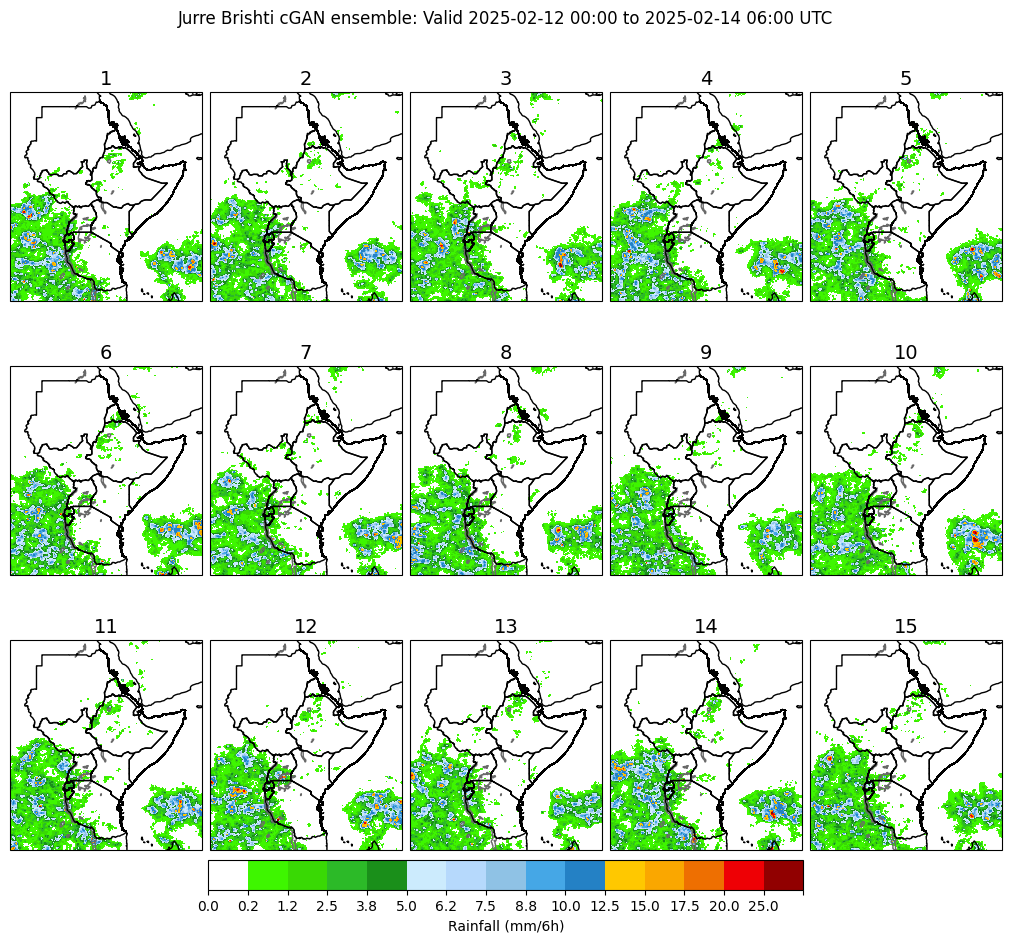

In [7]:
plot_GAN_ensemble(
    data,
    model="mvua-kubwa-ens",
    valid_time_start_hour="54h",
    style="KMD",
    plot_units="mm/6h",
    max_num_plots=15,
)

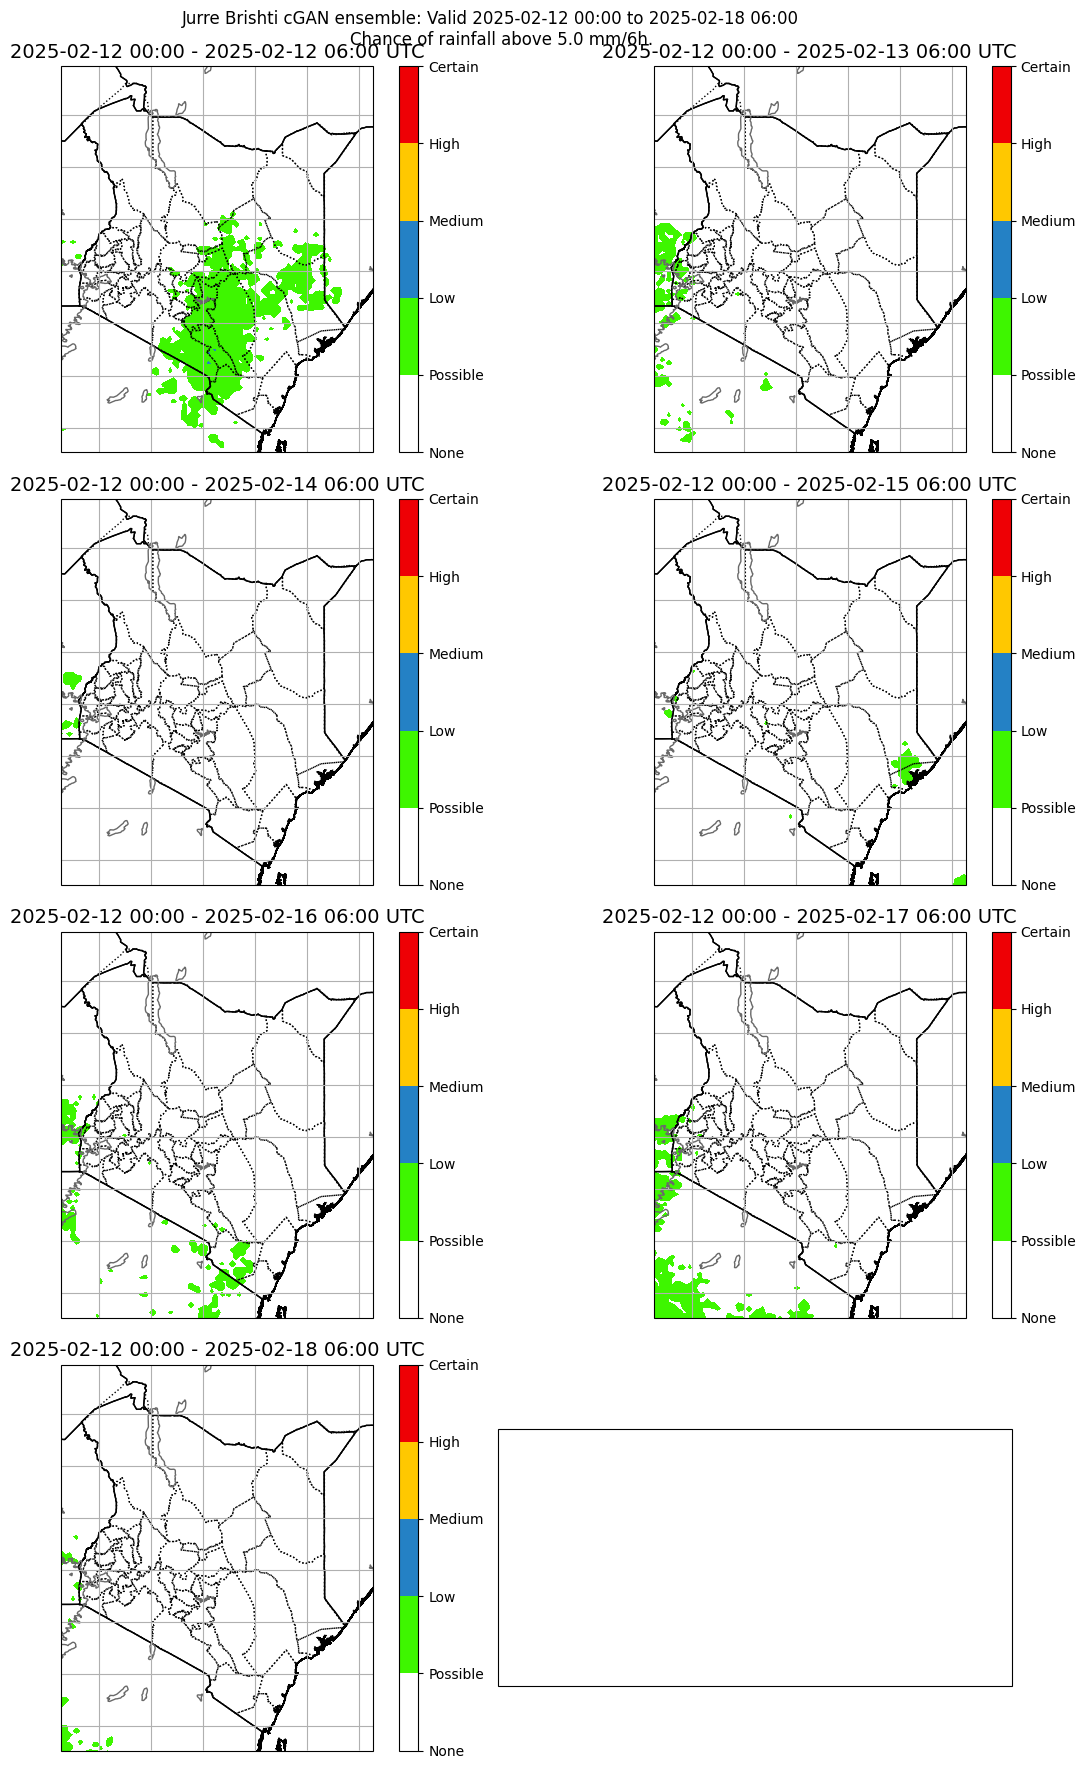

In [8]:
# Plot the chance of rainfall at a rate above a specified threshold.
#   threshold=2             - We'll plot the chance of rainfall above this threshold rate. The
#                             default is 2 mm/h. The units of threshold is set by plot_units.
#   plot_units='mm/h'       - Can be 'mm/h' (default), 'mm/6h', 'mm/day' or 'mm/week'
#   valid_time_start_hour=6 - The hour the valid time starts at. Can either be 6, 12, 18 or 0 UTC or 'all'.
#   style=None              - Can be 'ICPAC', 'KMD', 'EMI' or the default.
plot_GAN_threshold_chance(
    data,
    model="mvua-kubwa-ens",
    threshold=5,
    plot_units="mm/6h",
    valid_time_start_hour="all",
    style="KMD",
    show_percentages=False,
    region="Kenya",
)

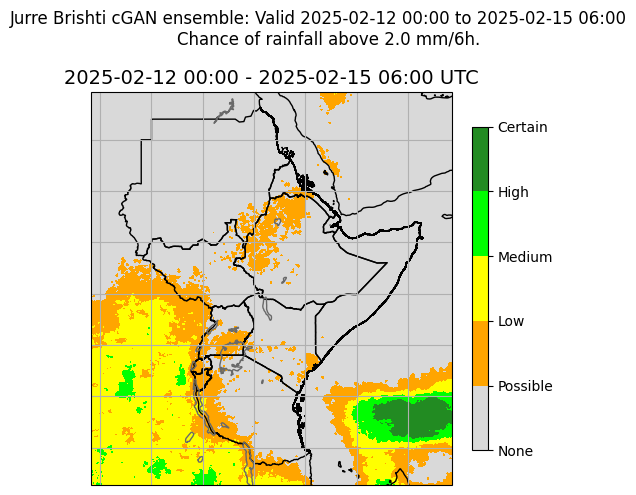

In [9]:
plot_GAN_threshold_chance(
    data,
    model="mvua-kubwa-ens",
    threshold=2,
    plot_units="mm/6h",
    valid_time_start_hour="78h",
    show_percentages=False,
    region=mask_region,
)